In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [151]:
article_df = pd.read_csv("articles_hm.csv")
customer_df = pd.read_csv("customer_hm.csv")
transaction_df = pd.read_csv("transactions_hm.csv")

In [152]:
whole_df = pd.merge(
    pd.merge(
        transaction_df,
        customer_df,
        on = 'customer_id'
    ),
    article_df,
    on ='article_id'
)
df = whole_df[['t_dat','customer_id','Active','age','section_no','section_name','garment_group_name','perceived_colour_master_name','index_group_no','index_group_name','product_type_no','product_type_name','price']].copy()
df['price'] = df['price']*1000

## ANOVA 검정
1. 가설 설정
2. 검정 방법 선택
3. 유의수준 결정
4. p-value,검정통계량 계산
5. 해석 - 귀무가설 채택 또는 기각

## 1. One-way ANOVA(일원 분산분석)

## Case1.  정규성 만족하지 않는 경우 

20대, 30대, 40대의 평균가격 비교 

In [153]:
df['age_group'] = df['age']/10
df['age_group'] = df['age_group'].astype(int)

In [154]:
df['age_group']

0         5
1         2
2         3
3         1
4         3
         ..
812926    2
812927    3
812928    4
812929    5
812930    4
Name: age_group, Length: 812931, dtype: int64

In [155]:
df_20 = df.loc[df['age_group']==2]
df_30 = df.loc[df['age_group']==3]
df_40 = df.loc[df['age_group']==4]

In [156]:
cust_20 = df_20.groupby("customer_id")['price'].mean()
cust_30 = df_30.groupby("customer_id")['price'].mean()
cust_40 = df_40.groupby("customer_id")['price'].mean()

In [157]:
len(cust_20), len(cust_30), len(cust_40)

(145921, 66100, 53264)

In [158]:
cust_20_sample = cust_20.sample(53264, random_state=42)
cust_30_sample = cust_30.sample(53264, random_state=42)
cust_40_sample = cust_40.copy()

2. 검정방법 선택
- 후보1: 일원 ANOVA
    - 조건에 맞는지 1)정규성 2)등분산성 3)독립성 

### 1) 정규성 확인하기

c:\basic_class_통계_수업\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


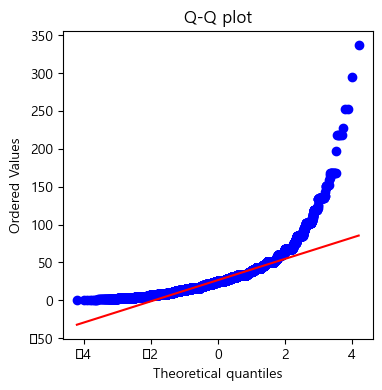

In [159]:
# q-q plot 

plt.figure(figsize=(4,4))
stats.probplot(cust_20_sample, plot=plt)
plt.title("Q-Q plot")
plt.show()

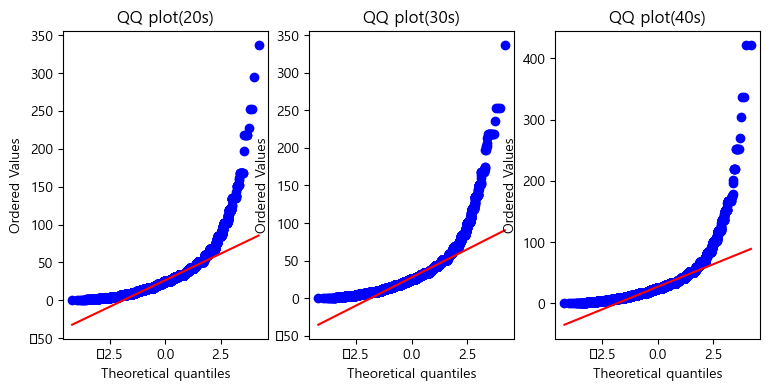

In [160]:
# q-q plot 시각화
fig, ax = plt.subplots(1,3, figsize=(9,4))
stats.probplot(cust_20_sample, plot=ax[0])
ax[0].set_title("QQ plot(20s)")
stats.probplot(cust_30_sample, plot=ax[1])
ax[1].set_title("QQ plot(30s)")
stats.probplot(cust_40_sample, plot=ax[2])
ax[2].set_title("QQ plot(40s)")
plt.show()

정규성을 만족하지 않음을 확인함.

3. 유의수준 결정
p-value :0.01

4. 검정 통계량, p-value 계산

그래서 Kruskal–Wallis (K-W)검정 사용

In [161]:
stat, p = stats.kruskal(cust_20_sample, cust_30_sample, cust_40_sample)
stat, p

(np.float64(32.511871188015796), np.float64(8.712381283045135e-08))

5. 결과해석

p-value가 유의수준보다 낮으니까 귀무가설 기각.

### 사후검정(Dunn test)

In [162]:
data = pd.DataFrame({
    'value':pd.concat([cust_20_sample,cust_30_sample,cust_40_sample]),
    'group':['20s']*53264+['30s']*53264+['40s']*53264
})
data


,value,group
customer_id,,
674a2dcccfcfe5ecb72b079a7cbd61192215104a63851b03ce047048eb1e45cb,15.24,20s
9b066fa9f79e0702135621d7467e2e62407ac3765ebae11ad0ac8ef799b14c26,25.41,20s
6e90434864e9f6048122d73ca5fa7f8f76c318f6fb284711b2356c0c5bff1a78,11.85,20s
5b5030e597b4367e3227d2b0d2b45a22930a61a3370fc639718dbc047cf65024,50.83,20s
a34b0f5219b4ec171cb87e65b3e54344112231e4881dc3ed6d3cdb5a1e0e9366,25.41,20s
...,...,...
c8885cb59d60566362d2bfccc093a17565d9ef5c4eb0b4380f36ceb0b98077e6,39.53,40s
c88af0a024aff8ae3d209ef45009c96e117eb94d49f0ceb588869dc4bbfbd3b2,42.36,40s
c88dbf3e75ef91ad363f823fa206ee213e823f7283668c385e128f73a7f4e7a6,49.93,40s


In [163]:
!pip install scikit_posthocs

In [164]:
import scikit_posthocs as sp
# Dunn 사후검정
posthoc = sp.posthoc_dunn(data, 
                        val_col="value",
                        group_col="group",
                        p_adjust="holm"
                        )
print(posthoc) 

     20s  30s  40s
20s 1.00 0.00 0.03
30s 0.00 1.00 0.00
40s 0.03 0.00 1.00


만약 저기에서 모든 검정시 0.05보다 작으면 값이 모두 같다로 나오나요?

In [165]:
posthoc

,20s,30s,40s
20s,1.00,0.00,0.03
30s,0.00,1.00,0.00
40s,0.03,0.00,1.00


--------------

### 정규성을 만족할 때

## Case2. 정규성, 등분산성 모두 만족할 때
일원 ANOVA 검정을 해야함

1. 가설설정
- 귀무가설 : a반 평균 = b반 평균 = c반 평균 
- 대립가설 : 적어도 한 반의 평균은 다르다. 

In [166]:
# 각 반의 점수
a = [61, 87, 79, 64, 90, 60, 52, 49, 51, 92, 72, 38, 77, 87, 39, 92, 99, 77, 49, 94, 76, 83, 45, 78, 91]
b = [54, 57, 75, 85, 62, 87, 83, 93, 77, 82, 52, 81, 26, 55, 42, 64, 69, 98, 58, 33, 46, 100, 50, 56, 31]
c = [49, 61, 69, 83, 75, 72, 48, 39, 29, 60, 37, 32, 50, 88, 97, 82, 42, 92, 49, 45, 59, 35, 79, 30, 36]

2. 검정방법 선택
- 후보1: 일원 ANOVA
    1) 정규성 2) 등분산성 3) 독립성 

2-1) 정규성 확인

c:\basic_class_통계_수업\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


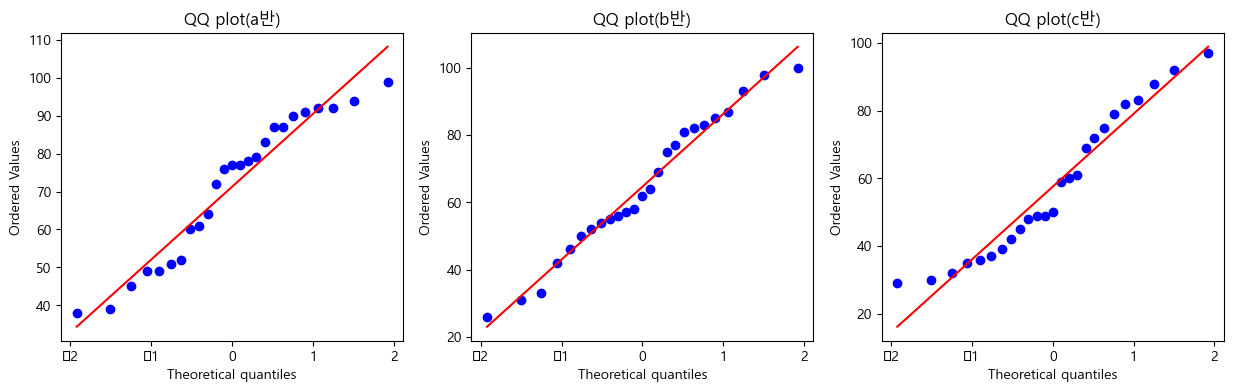

In [167]:
# q-q plot 시각화
fig, ax = plt.subplots(1,3, figsize=(15,4))
stats.probplot(a, plot=ax[0])
ax[0].set_title("QQ plot(a반)")
stats.probplot(b, plot=ax[1])
ax[1].set_title("QQ plot(b반)")
stats.probplot(c, plot=ax[2])
ax[2].set_title("QQ plot(c반)")
plt.show()

In [168]:
# 정규성 검정 2. Kolmogorov-Sminov

# 표본의 평균
sample_mean = np.mean(a)
# 표본의 표준편차 
s = np.std(a,ddof=1)

stat, p = stats.kstest(a, 'norm', args=(sample_mean, s))
stat, p

(np.float64(0.15840189108470354), np.float64(0.5071381949946883))

In [169]:
# 정규성 검정 2. Kolmogorov-Sminov

# 표본의 평균
sample_mean = np.mean(b)
# 표본의 표준편차 
s = np.std(b,ddof=1)

stat, p = stats.kstest(b, 'norm', args=(sample_mean, s))
stat, p

(np.float64(0.10444822684281829), np.float64(0.9217284808478653))

In [170]:
# 정규성 검정 2. Kolmogorov-Sminov

# 표본의 평균
sample_mean = np.mean(c)
# 표본의 표준편차 
s = np.std(c,ddof=1)

stat, p = stats.kstest(c, 'norm', args=(sample_mean, s))
stat, p

(np.float64(0.15913396483679465), np.float64(0.5013144035593511))

a,b,c 반 모두 점수가 정규분포를 따른다 

2) 등분산성 확인

In [171]:
stat, p = stats.levene(a,b,c)
stat, p

(np.float64(0.21055341835034663), np.float64(0.8106328207411082))

a반, b반, c반 점수의 분산이 같다. 
=> 일원 ANOVA 가능

3. 유의수준 결정 : 0.05

4. 검정통계량, p-value 계산하기

In [172]:
stat, p = stats.f_oneway(a,b,c)
stat, p

(np.float64(2.857691544316834), np.float64(0.06393197988004386))

- p-value가 유의수준(0.05)보다 높으므로 귀무가설 채택
- a반 b반 c반의 평균은 같다 

### 사후검정 : Tuckey HSD
- p-value < 유의수준 이었다고 가정하자.  

- p-value가 유의수준(0.1)보다 작으므로 귀무가설 기각
- a반 b반 c반의 평균은 적어도 하나는 다르다

In [173]:
np.reshape([a,b,c], shape=(-1,))

array([ 61,  87,  79,  64,  90,  60,  52,  49,  51,  92,  72,  38,  77,
        87,  39,  92,  99,  77,  49,  94,  76,  83,  45,  78,  91,  54,
        57,  75,  85,  62,  87,  83,  93,  77,  82,  52,  81,  26,  55,
        42,  64,  69,  98,  58,  33,  46, 100,  50,  56,  31,  49,  61,
        69,  83,  75,  72,  48,  39,  29,  60,  37,  32,  50,  88,  97,
        82,  42,  92,  49,  45,  59,  35,  79,  30,  36])

In [174]:
data = pd.DataFrame({
    'value':np.reshape([a,b,c], shape=(-1,)),
    'group':['a반']*25+['b반']*25+['c반']*25
})
data

,value,group
0,61,a반
1,87,a반
2,79,a반
3,64,a반
4,90,a반
...,...,...
70,59,c반
71,35,c반
72,79,c반
73,30,c반


In [175]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=data['value'],
                        groups =data['group'],
                        alpha=0.05)

In [176]:
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    a반     b반    -6.64 0.4848 -20.4168 7.1368  False
    a반     c반   -13.76 0.0503 -27.5368 0.0168  False
    b반     c반    -7.12 0.4356 -20.8968 6.6568  False
----------------------------------------------------


In [177]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=data['value'],
                        groups =data['group'],
                        alpha=0.1)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.10 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    a반     b반    -6.64 0.4848 -18.6459  5.3659  False
    a반     c반   -13.76 0.0503 -25.7659 -1.7541   True
    b반     c반    -7.12 0.4356 -19.1259  4.8859  False
-----------------------------------------------------


유의수준 0.1일 때, a반과 c반의 평균이 다르다

----

## Case3. 정규성은 만족하지만 등분산성은 만족하지 못하는 경우

1.가설 설정
- 귀무가설 : 색상별로 평균가격 차이가 없다(모두 같다)
- 대립가설 : 적어도 한 가지 색상은 평균 가격 차이가 있다. 

In [189]:
data_jersy = df.loc[df['garment_group_name']=='Jersey Fancy']

In [190]:
cust_price = data_jersy.groupby(['customer_id','perceived_colour_master_name'])['price'].mean().reset_index()

White, Yellow, Black 

In [191]:
# 이상치 제거
q_1 = np.percentile(cust_price['price'], q=25)
q_3 = np.percentile(cust_price['price'], q=75)
iqr = q_3 - q_1

lower_whisker = q_1 - 1.5*iqr
upper_whisker = q_3 + 1.5*iqr

cust_price_processed = cust_price.loc[cust_price['price'].between(lower_whisker,upper_whisker)]

In [192]:
cust_price_processed['perceived_colour_master_name'].value_counts()

perceived_colour_master_name
Black           39094
White           21720
Blue            10520
Grey             7579
Pink             7512
Beige            6560
Red              5691
Yellow           3528
Green            3117
Khaki green      2979
Unknown          2717
Orange           2209
Turquoise        1411
Brown            1330
Mole             1155
Lilac Purple      384
Metal              51
undefined          28
Name: count, dtype: int64

In [193]:
black_price = cust_price_processed.loc[cust_price_processed['perceived_colour_master_name']=='Black','price']
white_price = cust_price_processed.loc[cust_price_processed['perceived_colour_master_name']=='White','price']
blue_price = cust_price_processed.loc[cust_price_processed['perceived_colour_master_name']=='Blue','price']

In [194]:
black_price_sample = black_price.sample(10520,random_state=42)
white_price_sample = white_price.sample(10520,random_state=42)
blue_price_sample = blue_price.copy()

2. 검정방법 선택 후보1 : ANOVA

2-1) 정규성

c:\basic_class_통계_수업\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


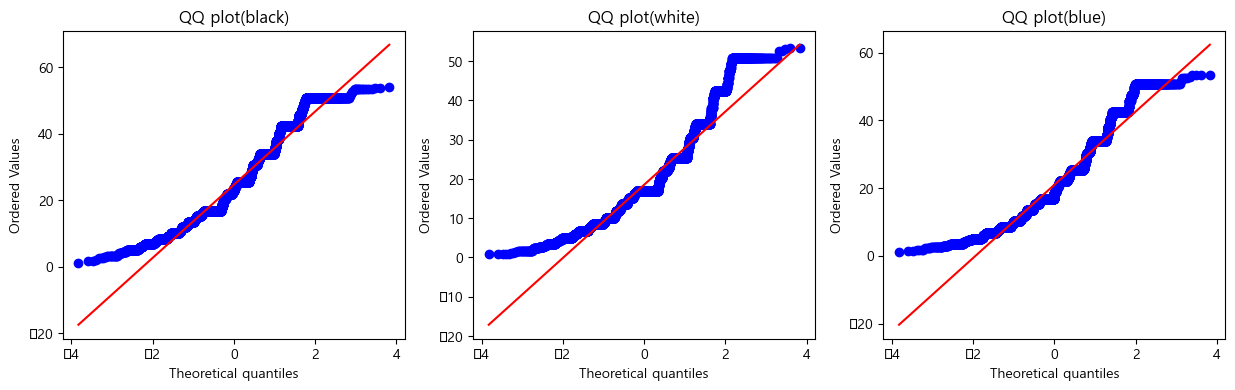

In [195]:
# q-q plot 시각화
fig, ax = plt.subplots(1,3, figsize=(15,4))
stats.probplot(black_price_sample, plot=ax[0])
ax[0].set_title("QQ plot(black)")
stats.probplot(white_price_sample, plot=ax[1])
ax[1].set_title("QQ plot(white)")
stats.probplot(blue_price_sample, plot=ax[2])
ax[2].set_title("QQ plot(blue)")
plt.show()

In [196]:
# 정규성 검정 2. Kolmogorov-Sminov

group = black_price_sample

# 표본의 평균
sample_mean = np.mean(group)
# 표본의 표준편차 
s = np.std(group,ddof=1)

stat, p = stats.kstest(group, 'norm', args=(sample_mean, s))
stat, p

(np.float64(0.1298435225652667), np.float64(4.275054356571467e-155))

In [197]:
# 정규성 검정 2. Kolmogorov-Sminov

group = white_price_sample

# 표본의 평균
sample_mean = np.mean(group)
# 표본의 표준편차 
s = np.std(group,ddof=1)

stat, p = stats.kstest(group, 'norm', args=(sample_mean, s))
stat, p

(np.float64(0.19625302392106214), np.float64(0.0))

In [198]:
# 정규성 검정 2. Kolmogorov-Sminov

group = blue_price_sample

# 표본의 평균
sample_mean = np.mean(group)
# 표본의 표준편차 
s = np.std(group,ddof=1)

stat, p = stats.kstest(group, 'norm', args=(sample_mean, s))
stat, p

(np.float64(0.13449493174498783), np.float64(2.0242849055697872e-166))

결과를 보았을 때, 세 그룹 모두 정규분포를 따르지 않는다. 따라서 원칙적으로 이 때에는 Kruskal-Walis 검정을 해야 하나 지금은 일단 정규성을 만족한다고 가정하고 넘어가겠음. 

In [199]:
stat, p = stats.levene(black_price_sample,white_price_sample,blue_price_sample)
stat, p  

(np.float64(288.01727952022736), np.float64(1.1056314520551534e-124))

등분산성을 만족하지 않는다. 

3. 유의 수준 결정 : 0.05

4. 검정통계량과 p-value 계산

In [202]:
!pip install pingouin

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 24.3 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ---------- ----------------------------- 1/4 [xarray]
   ------------------------------ --------- 3/4 [pingouin]
   ---------------------------------------- 4/4 [pingouin]



In [203]:
import pingouin as pg

In [204]:
data = pd.DataFrame({
    'value':np.reshape([black_price_sample,white_price_sample,blue_price_sample], shape=(-1,)),
    'group':['black']*10520+['white']*10520+['blue']*10520
})
data

,value,group
0,9.14,black
1,32.19,black
2,16.93,black
3,33.88,black
4,42.36,black
...,...,...
31555,25.41,blue
31556,30.49,blue
31557,22.02,blue
31558,25.41,blue


In [205]:
result = pg.welch_anova(data=data, dv='value', between='group')
result

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,20935.80,904.73,0.00,0.05


p-unc : p-value
p-value가 0이 나옴 -> 귀무가설 기각, 대립가설 채택

### 사후검정. Games -Howell

In [206]:
result = pg.pairwise_gameshowell(data=data, dv='value', between="group")
result

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,black,blue,24.69,21.00,3.69,0.15,23.93,21034.04,0.00,0.33
1,black,white,24.69,18.53,6.16,0.14,42.52,20589.17,0.00,0.59
2,blue,white,21.00,18.53,2.47,0.14,17.19,20665.79,0.00,0.24


p-value가 모두 0이 나옴 
>> 세 개 집단 모두 서로 가격이 다르다

## 카이제곱 독립성 검정 

In [211]:

ct = pd.crosstab(df['perceived_colour_master_name'], df['index_group_name'])
ct_2 = ct.loc[~ct.index.isin(['Metal','Yellowish Green','undefined'])]

In [212]:
from scipy.stats import chi2_contingency

result = chi2_contingency(ct_2)
result

Chi2ContingencyResult(statistic=np.float64(60164.35646386924), pvalue=np.float64(0.0), dof=60, expected_freq=array([[1.88697890e+03, 1.20259164e+04, 3.37562025e+04, 2.84855087e+03,
        1.93535126e+03],
       [9.96267877e+03, 6.34932071e+04, 1.78222556e+05, 1.50394884e+04,
        1.02180702e+04],
       [4.03714843e+03, 2.57291746e+04, 7.22206272e+04, 6.09440977e+03,
        4.14063998e+03],
       [7.05571030e+02, 4.49667891e+03, 1.26219740e+04, 1.06511788e+03,
        7.23658213e+02],
       [8.04537322e+02, 5.12740158e+03, 1.43923839e+04, 1.21451569e+03,
        8.25161489e+02],
       [1.68037642e+03, 1.07092169e+04, 3.00602867e+04, 2.53666732e+03,
        1.72345256e+03],
       [8.00616084e+02, 5.10241111e+03, 1.43222368e+04, 1.20859626e+03,
        8.21139731e+02],
       [1.04578340e+02, 6.66488839e+02, 1.87080397e+03, 1.57869662e+02,
        1.07259187e+02],
       [2.88840555e+02, 1.84081145e+03, 5.16707434e+03, 4.36028729e+02,
        2.96244929e+02],
       [6.30887633